In [1]:
import pandas as pd
import numpy as np

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-14 09:38:08--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8002::154, 2606:50c0:8003::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.01s   

2025-10-14 09:38:08 (5.80 MB/s) - ‘course_lead_scoring.csv’ saved [80876/80876]



In [25]:
data = pd.read_csv("course_lead_scoring.csv")

In [26]:
data

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

features = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']
target = 'converted'

# Drop rows with missing values in selected columns
df_clean = data[features + [target]].dropna()

# Split into train and test sets
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Compute ROC AUC for each feature as a standalone predictor
auc_scores = {}

for feature in features:
    score = X_train[feature]
    auc = roc_auc_score(y_train, score)

    # Invert score if AUC < 0.5
    if auc < 0.5:
        score = -score
        auc = roc_auc_score(y_train, score)

    auc_scores[feature] = auc

# Sort features by AUC descending
sorted_auc = sorted(auc_scores.items(), key=lambda x: x[1], reverse=True)

# Print results
for feature, auc in sorted_auc:
    print(f"{feature}: AUC = {auc:.4f}")

number_of_courses_viewed: AUC = 0.7800
interaction_count: AUC = 0.7265
lead_score: AUC = 0.6167
annual_income: AUC = 0.5529


In [31]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression


X_train, X_val, y_train, y_val = train_test_split(
    df_clean.drop(columns='converted'), df_clean['converted'], stratify=df_clean['converted'], random_state=42
)

# Convert data to dictionary format for DictVectorizer
train_dicts = X_train.to_dict(orient='records')
val_dicts = X_val.to_dict(orient='records')

# Apply one-hot encoding
dv = DictVectorizer(sparse=False)
X_train_encoded = dv.fit_transform(train_dicts)
X_val_encoded = dv.transform(val_dicts)

# Train logistic regression model
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train_encoded, y_train)

# Predict probabilities and calculate AUC on validation set
y_val_probs = model.predict_proba(X_val_encoded)[:, 1]
auc = roc_auc_score(y_val, y_val_probs)
round(auc, 3)

np.float64(0.79)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


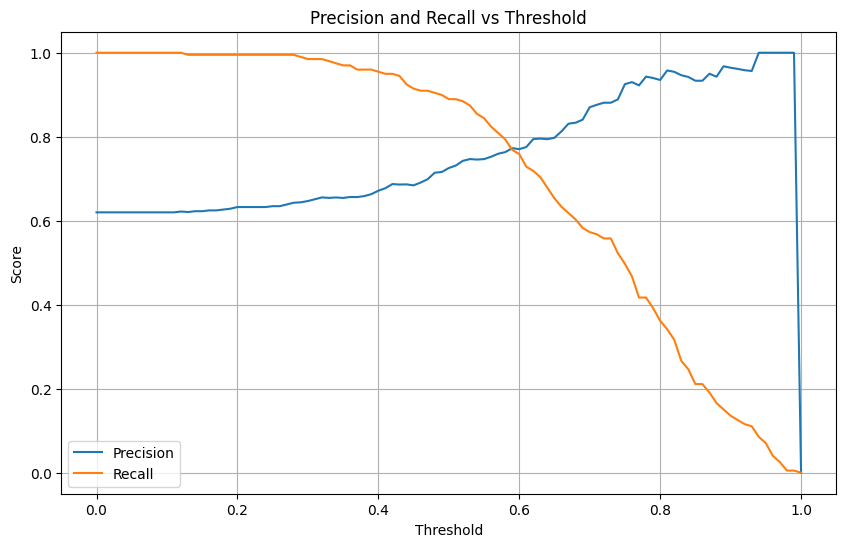

np.float64(1.0)

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Generate thresholds from 0.0 to 1.0 with step 0.01
thresholds = np.arange(0.0, 1.01, 0.01)

# Store precision and recall for each threshold
precisions = []
recalls = []

# Evaluate precision and recall at each threshold
for t in thresholds:
    y_pred = (y_val_probs >= t).astype(int)
    precisions.append(precision_score(y_val, y_pred))
    recalls.append(recall_score(y_val, y_pred))

# Plot precision and recall curves
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Find threshold where precision and recall curves intersect (min absolute difference)
precision_recall_diff = np.abs(np.array(precisions) - np.array(recalls))
intersection_idx = np.argmin(precision_recall_diff)
intersection_threshold = thresholds[intersection_idx]
round(intersection_threshold, 3)

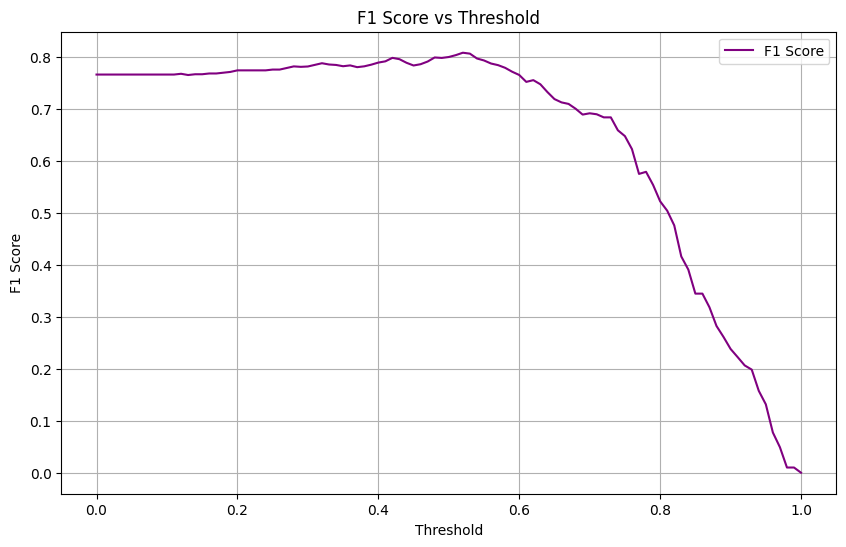

np.float64(0.52)

In [33]:
f1_scores = []

for p, r in zip(precisions, recalls):
    if p + r == 0:
        f1_scores.append(0)
    else:
        f1_scores.append(2 * p * r / (p + r))

# Find the threshold with the maximum F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# Plot F1 vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1 Score', color='purple')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

round(best_threshold, 3)

In [34]:
from sklearn.model_selection import KFold

# Prepare the data
df_full_train = df_clean.copy()
X_full = df_full_train.drop(columns='converted')
y_full = df_full_train['converted']

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Store AUC scores for each fold
auc_scores = []

# Perform cross-validation
for train_idx, val_idx in kf.split(df_full_train):
    X_train_cv = X_full.iloc[train_idx]
    y_train_cv = y_full.iloc[train_idx]
    X_val_cv = X_full.iloc[val_idx]
    y_val_cv = y_full.iloc[val_idx]

    # Convert to dictionaries for DictVectorizer
    train_dicts_cv = X_train_cv.to_dict(orient='records')
    val_dicts_cv = X_val_cv.to_dict(orient='records')

    # One-hot encode
    dv = DictVectorizer(sparse=False)
    X_train_enc = dv.fit_transform(train_dicts_cv)
    X_val_enc = dv.transform(val_dicts_cv)

    # Train logistic regression model
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train_enc, y_train_cv)

    # Predict and evaluate AUC
    y_val_probs_cv = model.predict_proba(X_val_enc)[:, 1]
    auc = roc_auc_score(y_val_cv, y_val_probs_cv)
    auc_scores.append(auc)

# Compute standard deviation of AUC scores
std_auc = np.std(auc_scores)
round(std_auc, 3)

np.float64(0.03)

In [35]:
# Define the list of C values to evaluate
C_values = [0.000001, 0.001, 1]

# Store results for each C value
results = []

# Perform cross-validation for each C
for C_val in C_values:
    auc_scores = []

    for train_idx, val_idx in kf.split(df_full_train):
        X_train_cv = X_full.iloc[train_idx]
        y_train_cv = y_full.iloc[train_idx]
        X_val_cv = X_full.iloc[val_idx]
        y_val_cv = y_full.iloc[val_idx]

        # Convert to dictionaries for DictVectorizer
        train_dicts_cv = X_train_cv.to_dict(orient='records')
        val_dicts_cv = X_val_cv.to_dict(orient='records')

        # One-hot encode
        dv = DictVectorizer(sparse=False)
        X_train_enc = dv.fit_transform(train_dicts_cv)
        X_val_enc = dv.transform(val_dicts_cv)

        # Train logistic regression with current C
        model = LogisticRegression(solver='liblinear', C=C_val, max_iter=1000)
        model.fit(X_train_enc, y_train_cv)

        # Predict and evaluate AUC
        y_val_probs_cv = model.predict_proba(X_val_enc)[:, 1]
        auc = roc_auc_score(y_val_cv, y_val_probs_cv)
        auc_scores.append(auc)

    # Record mean and std for this C
    mean_auc = round(np.mean(auc_scores), 3)
    std_auc = round(np.std(auc_scores), 3)
    results.append((C_val, mean_auc, std_auc))

results_sorted = sorted(results, key=lambda x: (-x[1], x[2], x[0]))  # sort by mean desc, std asc, C asc
results_sorted

[(0.001, np.float64(0.858), np.float64(0.018)),
 (1, np.float64(0.83), np.float64(0.03)),
 (1e-06, np.float64(0.552), np.float64(0.046))]